First we import the packages

In [1]:
from pygmid import Lookup as look_up
import numpy as np
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from si_prefix import si_format as num2eng
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

Now we import the lookup table

In [2]:
#import the lookup table
nch_path = 'C:/Users/atorralba/Documents/GitHub/Analog-ICDesign-OpenTools/gmID-Design/PDKs/gf180mcuD/nfet_03v3.mat'
pch_path = 'C:/Users/atorralba/Documents/GitHub/Analog-ICDesign-OpenTools/gmID-Design/PDKs/gf180mcuD/pfet_03v3.mat'

nch = look_up(nch_path)
pch = look_up(pch_path)

Now we will learn to design current mirrors

For this, we will see 3 commonly used current mirror topologies.
Simple
Cascode
Low-Voltage or High-Swing Cascode

First we will start with the Simple current mirror

This is a transistor that operates as a current source.
We need to consider what is important in a current mirror, fortunately the current mirror does not carry any signal so the important parameters are:

- Output Impedance
- Transistor Size
- VDSat 
- Flicker and Thermal noise*

The output impedance of a simple current mirror is:

ro = 1/gds

ro = 1/ID/gds/ID = 1/ID/gdsID = 1/(gdsID*ID)

We can sweep gmID and L to define VDSat
Once VDSat is set, we can Sweep L and ID to see how ro varies



Look up warning: GM_ID input larger than maximum! Output is NaN
Look up warning: GM_ID input larger than maximum! Output is NaN


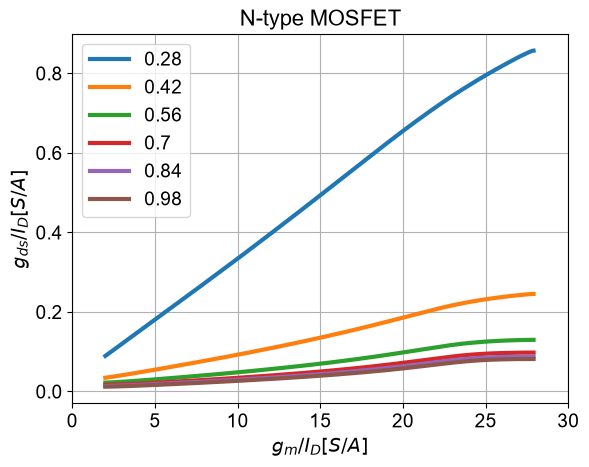

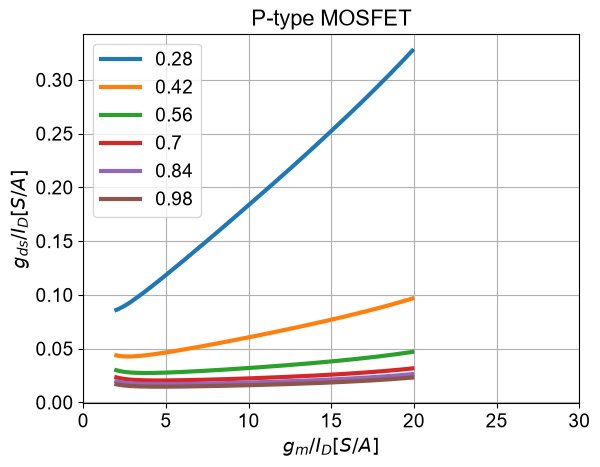

look_upVGS: GM_ID input larger than maximum!
look_upVGS: GM_ID input larger than maximum!


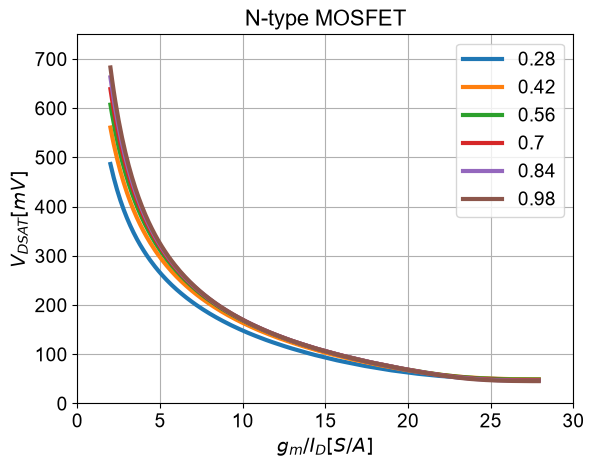

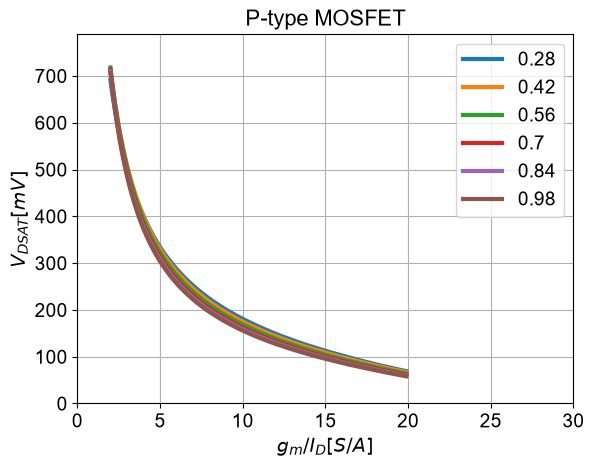

In [3]:
# Plot gmID vs gdsID and VDSat for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 28, 0.1)
gmIDP = np.arange(2, 20, 0.1)
LN = np.arange(min(nch['L']),4*min(nch['L']),0.5*min(nch['L']))
LP = np.arange(min(pch['L']),4*min(pch['L']),0.5*min(pch['L']))

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

plt.plot(gmIDN, np.transpose(gdsIDN), linewidth = 3)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


plt.plot(gmIDP, np.transpose(gdsIDP), linewidth = 3)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


VGSN = []
VDSatN = []
VGSP = []
VDSatP = []
for L in LN:
    tVGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L = L)
    VGSN.append(tVGSN)
    tVDSATN = nch.look_up('VDSAT',vgs = tVGSN, vds=VDS, vsb=VSB, L=L)
    VDSatN.append(tVDSATN)
    tVGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L = L)
    VGSP.append(tVGSP)
    tVDSATP = pch.look_up('VDSAT',vgs = tVGSP, vds=VDS, vsb=VSB, L=L)
    VDSatP.append(tVDSATP)

plt.plot(gmIDN, np.transpose(VDSatN)*1e3, linewidth = 3, label=LN)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatN).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDP, np.transpose(VDSatP)*1e3, linewidth = 3, label=LP)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatP).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()





We have fixed gmID to 10 and now we will sweep ro to see how the current and L affect the output impedance


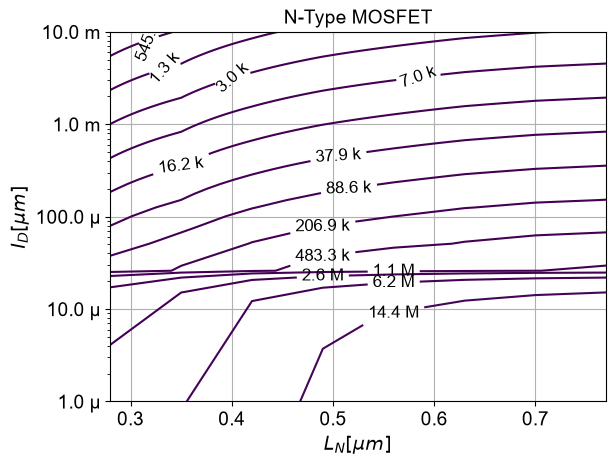

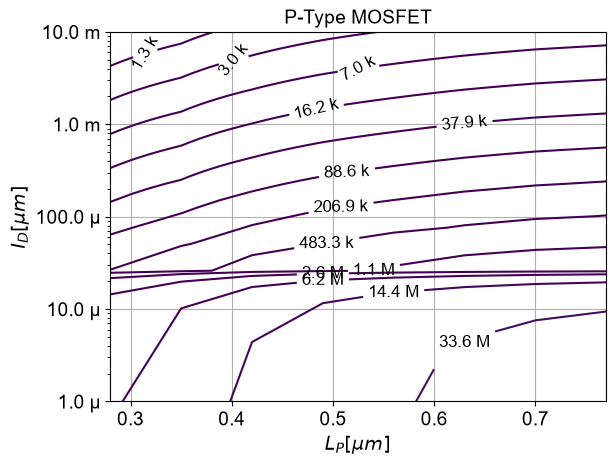

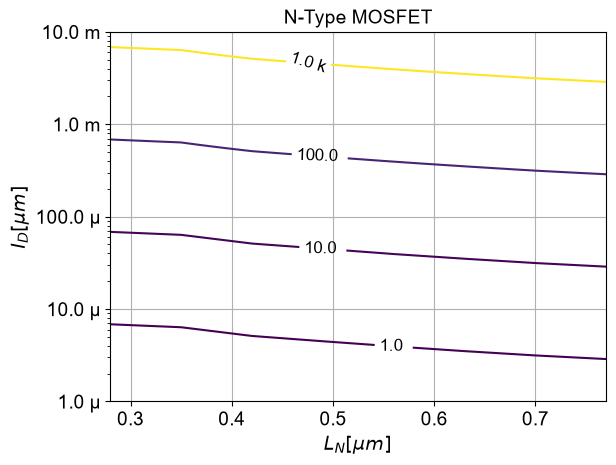

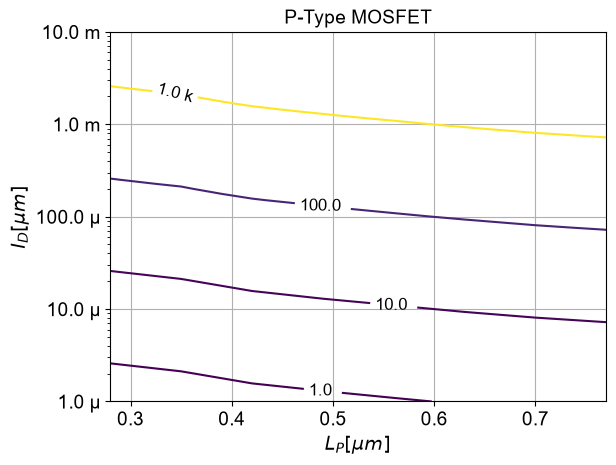

In [4]:
# We set a gmIDN at a fixed value and then we sweep L and ID to get ro.

VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = 10
gmIDP = 10
LN = np.arange(min(nch['L']),3*min(nch['L']),0.25*min(nch['L']))
LP = np.arange(min(pch['L']),3*min(pch['L']),0.25*min(pch['L']))
ID = np.arange(1, 10000, 25)*1e-6

# ro = 1/(gdsID*ID)
# We need to generate a contour plot sweeping L in the x axis and ID in the y axis, and then plotting the contours of ro.

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

# gdsIDN and gdsIDP are a vector dependent on L
# L will be on the x axis of the contour plot
# ID will be on the y axis of the contour plot however ID is a single number so we have:
# 
# IDN
# ...
# ID2
# ID1
# ID0 
#     LN0 LN1 LN2 ... LNN 

# However ID0 to IDN have the same value so we may create a vector with the same size as LN filled with the same value of ID

# ID01 ID  ID  ID      ID
# ID0  ID  ID  ID      ID
#     LN0 LN1 LN2 ... LNN 

roN = 1/(gdsIDN*ID[:, np.newaxis])
roP = 1/(gdsIDP*ID[:, np.newaxis])

#JD = ID/W
#W = ID/JD
WN = ID[:, np.newaxis]/JDN
WP = ID[:, np.newaxis]/JDP

#Levels in logaritmic scale 
rlevels = np.logspace(2,9,20)
CS = plt.contour(LN, ID, roN, levels=rlevels, cmap='viridis')
plt.clabel(CS, fmt=lambda x: num2eng(x), inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_{N} [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$I_{D} [\mu m]$', weight='normal',fontsize=14)
plt.xlim(min(LN), max(LN))
plt.ylim(min(ID), max(ID))
plt.xscale('linear')
plt.yscale('log')
plt.title(r'N-Type MOSFET',weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
ytickslabel = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14)
plt.grid()
plt.show()


rlevels = np.logspace(2,9,20)
CS = plt.contour(LP, ID, roP, levels=rlevels, cmap='viridis')
plt.clabel(CS, fmt=lambda x: num2eng(x), inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_{P} [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$I_{D} [\mu m]$', weight='normal',fontsize=14)
plt.xlim(min(LP), max(LP))
plt.ylim(min(ID), max(ID))
plt.xscale('linear')
plt.yscale('log')
plt.title(r'P-Type MOSFET',weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
ytickslabel = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14)
plt.grid()
plt.show()


#Generate the contour plot with a semilog scale for the y axis
wlevels = [1,10,100,1000]
CS = plt.contour(LN, ID, WN, levels=wlevels, cmap='viridis')
plt.clabel(CS, fmt=lambda x: num2eng(x), inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_{N} [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$I_{D} [\mu m]$', weight='normal',fontsize=14)
#plt.xlim(min(LN), max(LN))
#plt.ylim(min(ID), max(ID))
plt.xscale('linear')
plt.yscale('log')
plt.title(r'N-Type MOSFET',weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
ytickslabel = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14)
plt.grid()
plt.show()


#Generate the contour plot with a semilog scale for the y axis
wlevels = [1,10,100,1000]
CS = plt.contour(LP, ID, WP, levels=wlevels, cmap='viridis')
plt.clabel(CS, fmt=lambda x: num2eng(x), inline=True, fontsize=12, colors='black')
plt.xlabel(r'$L_{P} [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$I_{D} [\mu m]$', weight='normal',fontsize=14)
#plt.xlim(min(LN), max(LN))
#plt.ylim(min(ID), max(ID))
plt.xscale('linear')
plt.yscale('log')
plt.title(r'P-Type MOSFET',weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
ytickslabel = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14)
plt.grid()
plt.show()


We see that the output impedance increases with a higher ID and L. 
However at high currents the output impedadence does not vary much

Now lets design a current mirror with the following requirements

VDSat = 180mV
ID = 100uA
W < 60um
ro as high as possible

In [ ]:
# First we know that gdsID does not vary that much with gmID so we can select it based on the VDSat requirements
# Using the previous plot we see that VDSat(gmID=12)=150mV so lets test it.

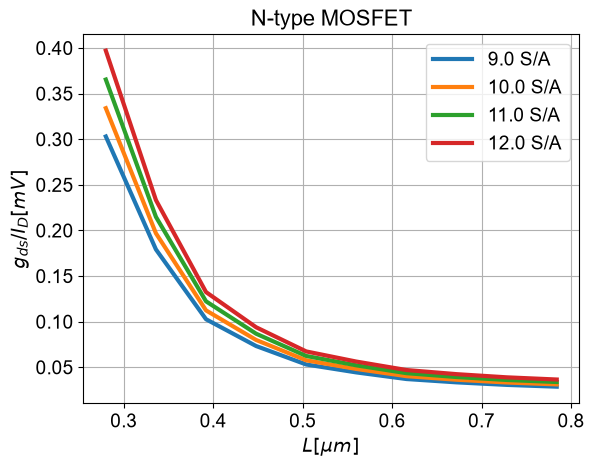

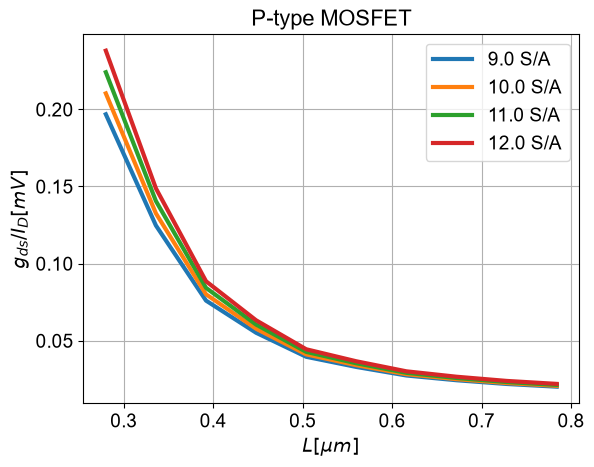

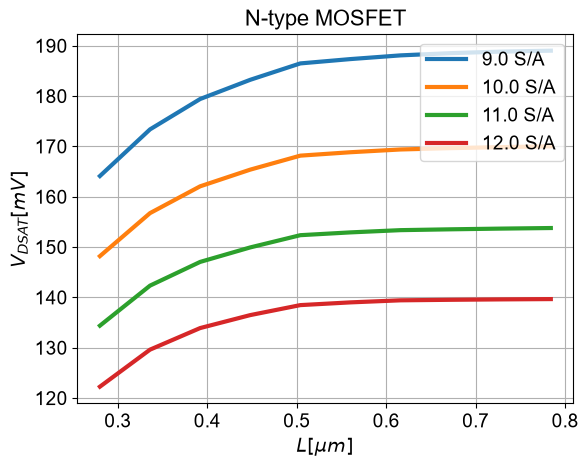

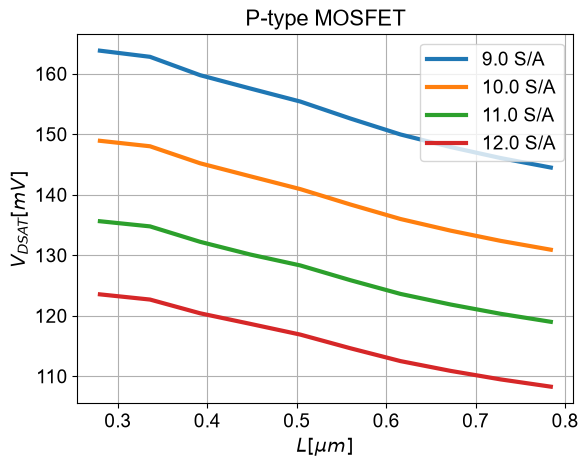

In [5]:
# Plot gmID vs gdsID and VDSat for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(9,13,1)
gmIDP = np.arange(11,15,1)
LN = np.arange(min(nch['L']),3*min(nch['L']),0.2*min(nch['L']))
LP = np.arange(min(nch['L']),3*min(nch['L']),0.2*min(nch['L']))


gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

# Save the VGS values for each L in a list
VGSN = []
VDSatN = []
VGSP = []
VDSatP = []
for L in LN:
    tVGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L = L)
    VGSN.append(tVGSN)
    tVGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L = L)
    VGSP.append(tVGSP)
    tVDSATN = nch.look_up('VDSAT',vgs = tVGSN, vds=VDS, vsb=VSB, L=L)
    VDSatN.append(tVDSATN)
    tVDSATP = pch.look_up('VDSAT',vgs = tVGSP, vds=VDS, vsb=VSB, L=L)
    VDSatP.append(tVDSATP)

#Another way to generate the loop
#VGSN = np.zeros(len(LN))
#VDSatN = np.zeros(len(LN))
#for i in range(len(LN)):
#    VGSN[i] = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L = LN[i])
#    VDSatN[i] = nch.look_up('VDSAT',vgs = VGSN[i], vds=VDS, vsb=VSB, L=LN[i])

plt.plot(LN, gdsIDN, linewidth = 3)
plt.legend([f'{num2eng(gmID)}S/A' for gmID in gmIDN],prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(LP, gdsIDP, linewidth = 3)
plt.legend([f'{num2eng(gmID)}S/A' for gmID in gmIDN],prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()


plt.plot(LN, np.array(VDSatN)*1e3, linewidth = 3)
plt.legend([f'{num2eng(gmID)}S/A' for gmID in gmIDN],prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(LP, np.array(VDSatP)*1e3, linewidth = 3)
plt.legend([f'{num2eng(gmID)}S/A' for gmID in gmIDN],prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()


Now lets see how large the transistor gets as we increment L

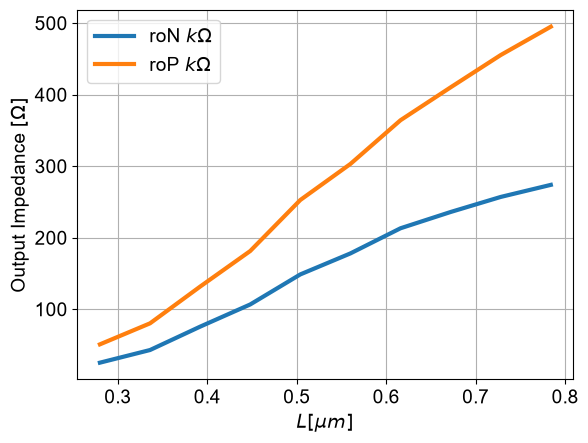

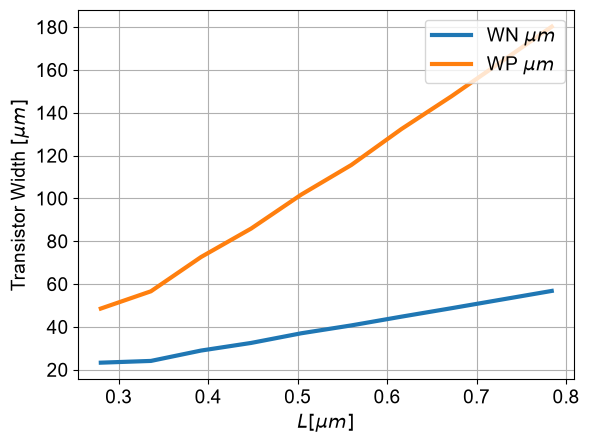

In [6]:
# We set a gmIDN at a fixed value and then we sweep L and ID to get ro.

VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = 12
gmIDP = 11
LN = np.arange(min(nch['L']),3*min(nch['L']),0.2*min(nch['L']))
LP = np.arange(min(nch['L']),3*min(nch['L']),0.2*min(nch['L']))
ID = 100e-6

# ro = 1/(gdsID*ID)
# We need to generate a contour plot sweeping L in the x axis and ID in the y axis, and then plotting the contours of ro.

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

roN = 1/(gdsIDN*ID)
roP = 1/(gdsIDP*ID)
#JD = ID/W
#W = ID/JD
WN = ID/JDN
WP = ID/JDP

plt.plot(LN, roN*1e-3, linewidth = 3,label=r'roN $k\Omega$')
plt.plot(LP, roP*1e-3, linewidth = 3,label=r'roP $k\Omega$')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.xlabel(r'$L [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'Output Impedance $[\Omega]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()


plt.plot(LN, WN, linewidth = 3,label=r'WN $\mu m$')
plt.plot(LP, WP, linewidth = 3,label=r'WP $\mu m$')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.xlabel(r'$L [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'Transistor Width $[\mu m]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()




We see that the maximum size is defined by L
LN = 600n
LP = 400n

In [7]:
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = 10
gmIDP = 10
LN = 0.6
LP = 0.4
ID = 100e-6

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

roN = 1/(gdsIDN*ID)
roP = 1/(gdsIDP*ID)
WN = ID/JDN
WP = ID/JDP
gmN = gmIDN*ID
gmP = gmIDP*ID

VGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L =LN)
VGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L =LP)
VDSatN = nch.look_up('VDSAT',vgs = VGSN, vds=VDS, vsb=VSB, L=LN)
VDSatP = pch.look_up('VDSAT',vgs = VGSP, vds=VDS, vsb=VSB, L=LP)


table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDN)) + " S/A", num2eng(float(gmIDP)) + " S/A"])
table.add_row(["L", str(LN) + " um", str(LP) + " um"])
table.add_row(["W", str(round(WN,1)) + " um", str(round(WP,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSN)) + "V", num2eng(float(VGSP)) + "V"])
table.add_row(["VDSat", num2eng(float(VDSatN)) + "V", num2eng(float(VDSatP)) + "V"])
table.add_row(["ro", num2eng(float(roN)) + "Ohms", num2eng(float(roP)) + "Ohms"])
table.add_row(["gm", num2eng(float(gmN)) + "S", num2eng(float(gmP)) + "S"])
table.add_row(["ID", num2eng(float(ID)) + "A", num2eng(float(ID)) + "A"])
print(table)





+-----------+-------------+-------------+
| Parameter |     NMOS    |     PMOS    |
+-----------+-------------+-------------+
|    gmID   |  10.0  S/A  |  10.0  S/A  |
|     L     |    0.6 um   |    0.4 um   |
|     W     |   27.3 um   |   61.1 um   |
|    VGS    |   839.5 mV  |   929.6 mV  |
|   VDSat   |   169.3 mV  |   175.8 mV  |
|     ro    | 242.0 kOhms | 151.2 kOhms |
|     gm    |    1.0 mS   |    1.0 mS   |
|     ID    |   100.0 µA  |   100.0 µA  |
+-----------+-------------+-------------+


Now lets consider the case of the cascode amplifier
Here we know that the output impedance equals

Rout = (1+(gm2+gmb2)ro2)ro1 + ro2

We may convert the resistances into conductances

Rout = (1+(gm2+gmb2)(1/gds2))(1/gds1) + 1/gds2

  1 + (gm2 + gmb2)     1         1
 (--------------- )  ----   +  ------
      gds2           gds1      gds2


Remember: the new swing changes to 2*VDSat, and at the gate of the transistors we require 2VGS 

(1 + gm2 + gmb2)/(gds2*gds1) + gds2

We may use the same transistor sizing to ease the calculations, that is gm1=gm2

ro_casc = (1 + gm + gmb)/(gds*gds) + gds


We may use the same simple current mirror design to see how the impedance changes.

In [8]:
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = 10
gmIDP = 10
LN = 0.6
LP = 0.4
ID = 100e-6

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

VGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L =LN)
VGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L =LP)
VDSatN = nch.look_up('VDSAT',vgs = VGSN, vds=VDS, vsb=VSB, L=LN)
VDSatP = pch.look_up('VDSAT',vgs = VGSP, vds=VDS, vsb=VSB, L=LP)

WN = ID/JDN
WP = ID/JDP
gmN = gmIDN*ID
gmP = gmIDP*ID
gdsN = gdsIDN*ID
gdsP = gdsIDP*ID


roN = 1/(gdsN)
roP = 1/(gdsP)
roN_casc = (1+gmN/gdsN)/gdsN+(1/gdsN)
roP_casc = (1+gmP/gdsP)/gdsP+(1/gdsP)

table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDN)) + " S/A", num2eng(float(gmIDP)) + " S/A"])
table.add_row(["L", str(LN) + " um", str(LP) + " um"])
table.add_row(["W", str(round(WN,1)) + " um", str(round(WP,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSN)) + "V", num2eng(float(VGSP)) + "V"])
table.add_row(["2*VGS", num2eng(float(2*VGSN)) + "V", num2eng(float(2*VGSP)) + "V"])
table.add_row(["VDSat", num2eng(float(VDSatN)) + "V", num2eng(float(VDSatP)) + "V"])
table.add_row(["2*VDSat", num2eng(float(2*VDSatN)) + "V", num2eng(float(2*VDSatP)) + "V"])
table.add_row(["ro", num2eng(float(roN)) + "Ohms", num2eng(float(roP)) + "Ohms"])
table.add_row(["ro Casc", num2eng(float(roN_casc)) + "Ohms", num2eng(float(roP_casc)) + "Ohms"])
table.add_row(["gm", num2eng(float(gmN)) + "S", num2eng(float(gmP)) + "S"])
table.add_row(["ID", num2eng(float(ID)) + "A", num2eng(float(ID)) + "A"])
print(table)


+-----------+-------------+-------------+
| Parameter |     NMOS    |     PMOS    |
+-----------+-------------+-------------+
|    gmID   |  10.0  S/A  |  10.0  S/A  |
|     L     |    0.6 um   |    0.4 um   |
|     W     |   27.3 um   |   61.1 um   |
|    VGS    |   839.5 mV  |   929.6 mV  |
|   2*VGS   |    1.7 V    |    1.9 V    |
|   VDSat   |   169.3 mV  |   175.8 mV  |
|  2*VDSat  |   338.6 mV  |   351.6 mV  |
|     ro    | 242.0 kOhms | 151.2 kOhms |
|  ro Casc  |  59.1 MOhms |  23.2 MOhms |
|     gm    |    1.0 mS   |    1.0 mS   |
|     ID    |   100.0 µA  |   100.0 µA  |
+-----------+-------------+-------------+


We see that the output impedance increases substantially 
However, the required VDSat also doubles and 2*VGS is a very high value.

Consider if we have a cascode current mirror instead of an ideal current source, if it is a pmos it requires a Vswing of 351mV, 2*VGSN=1V which leaves only 450mV. if we use a higher VDSat it may become a problem

In low voltage designs where VDD<1V the use of the regular cascode is not possible

Now Consider the Low-Swing Cascode Current mirror. 
Here we need to accomplish:

VGS1 = VDSat + VTHN
VGS2 > 2*VDSat + VTHN

With this in mind, we calculate the required VGS2 to bias the wide-swing current mirror

Denmostrate that VG > 2VDsat + VTH


VG = VGS2 + VDSat

2*VDsat = -VTH + VGS2 + VDSat => VGS2 = VDSat + VTH

VG = VDSat + VTH + VDSat
VG = 2*VDSat + VTH
VG > 2*VDsat + VTH

We may implement VG with a bias transistor where VGS2 = VG > 2*VDsat + VTH

In [9]:
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = 10
gmIDP = 10
LN = 0.6
LP = 0.4
ID = 100e-6

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

VGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L =LN)
VGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L =LP)
VDSatN = nch.look_up('VDSAT',vgs = VGSN, vds=VDS, vsb=VSB, L=LN)
VDSatP = pch.look_up('VDSAT',vgs = VGSP, vds=VDS, vsb=VSB, L=LP)
VTN = nch.look_up('VT',vgs = VGSN, vds=VDS, vsb=VSB, L=LN)
VTP = pch.look_up('VT',vgs = VGSP, vds=VDS, vsb=VSB, L=LP)

WN = ID/JDN
WP = ID/JDP
gmN = gmIDN*ID
gmP = gmIDP*ID
gdsN = gdsIDN*ID
gdsP = gdsIDP*ID


roN = 1/(gdsN)
roP = 1/(gdsP)
roN_casc = (1+gmN/gdsN)/gdsN+(1/gdsN)
roP_casc = (1+gmP/gdsP)/gdsP+(1/gdsP)


# For wide swing current mirror
VGSN2 = 2*VDSatN + VTN
VGSP2 = 2*VDSatP + VTP

#Lets find the gmID of a transistor with those values
gmIDN2 = nch.look_up('GM_ID',vgs = VGSN2, vds=VDS, vsb=VSB, L=LN)
gmIDP2 = nch.look_up('GM_ID',vgs = VGSN2, vds=VDS, vsb=VSB, L=LP)
JDN2 = nch.look_up('ID_W', GM_ID=gmIDN2, vds=VDS, vsb=VSB, L=LN)
JDP2 = pch.look_up('ID_W', GM_ID=gmIDP2, vds=VDS, vsb=VSB, L=LP)
WN2 = ID/JDN2
WP2 = ID/JDP2


table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDN)) + " S/A", num2eng(float(gmIDP)) + " S/A"])
table.add_row(["L", str(LN) + " um", str(LP) + " um"])
table.add_row(["W", str(round(WN,1)) + " um", str(round(WP,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSN)) + "V", num2eng(float(VGSP)) + "V"])
table.add_row(["2*VGS", num2eng(float(2*VGSN)) + "V", num2eng(float(2*VGSP)) + "V"])
table.add_row(["VDSat", num2eng(float(VDSatN)) + "V", num2eng(float(VDSatP)) + "V"])
table.add_row(["2*VDSat", num2eng(float(2*VDSatN)) + "V", num2eng(float(2*VDSatP)) + "V"])
table.add_row(["ro", num2eng(float(roN)) + "Ohms", num2eng(float(roP)) + "Ohms"])
table.add_row(["ro Casc", num2eng(float(roN_casc)) + "Ohms", num2eng(float(roP_casc)) + "Ohms"])
table.add_row(["gm", num2eng(float(gmN)) + "S", num2eng(float(gmP)) + "S"])
table.add_row(["ID", num2eng(float(ID)) + "A", num2eng(float(ID)) + "A"])
print(table)

print('Cascode Bias Generator')
table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDN2)) + " S/A", num2eng(float(gmIDP2)) + " S/A"])
table.add_row(["L", str(LN) + " um", str(LP) + " um"])
table.add_row(["W", str(round(WN2,1)) + " um", str(round(WP2,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSN2)) + "V", num2eng(float(VGSP2)) + "V"])
table.add_row(["ID", num2eng(float(ID)) + "A", num2eng(float(ID)) + "A"])
print(table)


+-----------+-------------+-------------+
| Parameter |     NMOS    |     PMOS    |
+-----------+-------------+-------------+
|    gmID   |  10.0  S/A  |  10.0  S/A  |
|     L     |    0.6 um   |    0.4 um   |
|     W     |   27.3 um   |   61.1 um   |
|    VGS    |   839.5 mV  |   929.6 mV  |
|   2*VGS   |    1.7 V    |    1.9 V    |
|   VDSat   |   169.3 mV  |   175.8 mV  |
|  2*VDSat  |   338.6 mV  |   351.6 mV  |
|     ro    | 242.0 kOhms | 151.2 kOhms |
|  ro Casc  |  59.1 MOhms |  23.2 MOhms |
|     gm    |    1.0 mS   |    1.0 mS   |
|     ID    |   100.0 µA  |   100.0 µA  |
+-----------+-------------+-------------+
Cascode Bias Generator
+-----------+----------+----------+
| Parameter |   NMOS   |   PMOS   |
+-----------+----------+----------+
|    gmID   | 4.9  S/A | 4.5  S/A |
|     L     |  0.6 um  |  0.4 um  |
|     W     |  6.6 um  | 12.9 um  |
|    VGS    |  1.0 V   |  1.1 V   |
|     ID    | 100.0 µA | 100.0 µA |
+-----------+----------+----------+
